In [25]:
#Import all libraries

import pandas as pd
import numpy as np
import re

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

from sklearn.model_selection import train_test_split

In [2]:
#Load the Stanford Sentiment Treebank 2 dataset

data = load_dataset("glue","sst2")
df = pd.DataFrame(data['train'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [3]:
#Viewing the dataset with labels

df = df[["sentence","label"]]
df.head()

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


In [4]:
# X-> input sentences , y-> output labels

X = df['sentence']
y = df['label']

In [5]:
# Tokenization

token = Tokenizer(num_words=10000)
token.fit_on_texts(X)

Xsequences = token.texts_to_sequences(X)

In [30]:
# Padding

m = 40
Xpadded = pad_sequences(Xsequences, maxlen = m)

In [31]:
# Train/Test Split

Xtrain, Xtest, ytrain, ytest = train_test_split(Xpadded,y, test_size=0.2,random_state=40)

In [36]:
# RNN Model Building

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32))
model.add(SimpleRNN(32, dropout=0.5))
model.add(Dense(1, activation="sigmoid"))

model.build(input_shape=(None, m))

In [37]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 40, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
hist = model.fit(
    Xtrain,
    ytrain,
    epochs=5,
    batch_size=32,
    validation_data=(Xtest,ytest)
)

Epoch 1/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.6845 - loss: 0.5657 - val_accuracy: 0.8647 - val_loss: 0.3267
Epoch 2/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8993 - loss: 0.2531 - val_accuracy: 0.9048 - val_loss: 0.2501
Epoch 3/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9254 - loss: 0.1929 - val_accuracy: 0.9105 - val_loss: 0.2461
Epoch 4/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9353 - loss: 0.1680 - val_accuracy: 0.9114 - val_loss: 0.2491
Epoch 5/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9415 - loss: 0.1500 - val_accuracy: 0.9139 - val_loss: 0.2496


In [39]:
# Calculate Validation Accuracy

loss,accuracy = model.evaluate(Xtest,ytest)

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9103 - loss: 0.2528


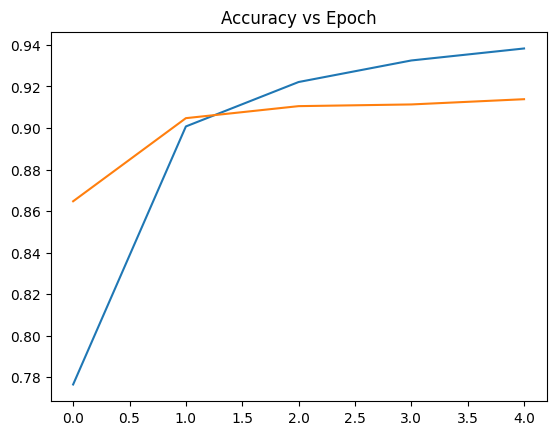

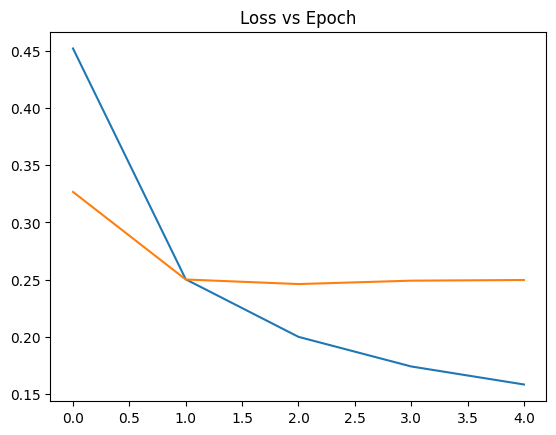

In [41]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy']); plt.plot(hist.history['val_accuracy'])
plt.title("Accuracy vs Epoch"); plt.show()

plt.plot(hist.history['loss']); plt.plot(hist.history['val_loss'])
plt.title("Loss vs Epoch"); plt.show()

In [44]:
# Custom input prediction
s = input("Enter a sentence: ").lower()

seq = token.texts_to_sequences([s])

padded = pad_sequences(seq,maxlen=m)

prediction = model.predict(padded)

if prediction[0][0] > 0.5:
    print("Sentiment: Positive :)")
else:
    print("Sentiment: Negative :(")

Enter a sentence: i was not happy with the product
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Sentiment: Negative :(
